# Covariance Structures and GLS: Workshop

## Applying to GLS to More Complex ANOVA Models

### Between-subjects Factors

### Multiple Within-subject Factors

## Covariance Structure Options
... Importantly, decisions between these structures either has to be *theoretically* motivated, or we have to use the *data* to see which structure has the most evidence in its favour. Although we can reason about the structure of this matrix, this is often quite hard to do in practice and needs quite deep knowledge of the phenomena under question. As such, it is much more typical to consider all possible *reasonable* structures and then use model comparisons to choose between them. For the moment, we will focus on the structures, but at the end of this part of the lesson we will see how to use the *data* to choose between them.

So, in terms of *reasonable* structures, we will constraint ourselves to either *fixing* all correlations to a single value (i.e. compound symmetry) or allowing all correlations to *freely vary* (i.e. an unconstrained structure). On top of this, we can also consider *fixing* all variances to a single value (i.e. homogeneity of variance) or allowing all variances to *freely vary* (i.e. heterogeneity of variance). So this gives us 4 possible combinations of `correlation` and `weights` structures to try.

Marginal variance covariance matrix
          [,1]      [,2]     [,3]
[1,]  0.327720 -0.073454 -0.10269
[2,] -0.073454  0.682240 -0.14817
[3,] -0.102690 -0.148170  1.33340
  Standard Deviations: 0.57247 0.82598 1.1548 


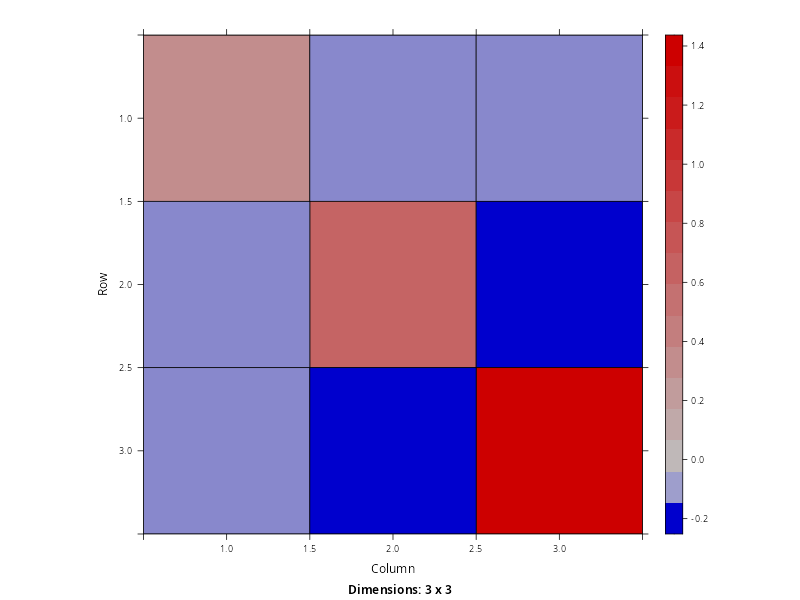

In [ ]:
gls.mod <- gls(score ~ time, correlation=corCompSymm(form= ~ 1|id), weights=varIdent(form= ~ 1|time), data=selfesteem.long)

Sigma.1 <- getVarCov(gls.mod, individual='1')
print(Sigma.1)
image(as(Sigma.1, "Matrix"))

So, here we can see that we have created a variance-covariance matrix where *both* the diagonal and off-diagonal elements are not different. However, this has been achieved using only a *single* correlation parameter. So, in reality, the correlation between the repeated measurements remains *fixed*. We can see this by converting the variance-covariance matrix into a correlation matrix, using the `cov2cor()` function 

In [ ]:
print(cov2cor(Sigma.1))

Marginal variance covariance matrix
         [,1]     [,2]     [,3]
[1,]  1.00000 -0.15534 -0.15534
[2,] -0.15534  1.00000 -0.15534
[3,] -0.15534 -0.15534  1.00000
  Standard Deviations: 1 1 1 


So, the only reason the covariance is *different* is because the correlation is being scaled differently by the different variances. So do not be mislead. This structure is exactly what you would get from allowing heterogeneity of variance, even with a fixed correlation. So despite appearances, this is still quite a *restrictive structure*.

In order to allow the correlations to *actually differ* between the repeated measurements, we need to use the `corSymm()` structure. This specifies an *unstructured* symmetric covariance matrix, where each off-diagonal element can be *any value*. This allows the data to determine the magnitude and direction of each individual correlation between the repeated measurements.

Marginal variance covariance matrix
         [,1]     [,2]     [,3]
[1,]  0.76920 -0.23823  0.21441
[2,] -0.23823  0.76920 -0.33831
[3,]  0.21441 -0.33831  0.76920
  Standard Deviations: 0.87704 0.87704 0.87704 


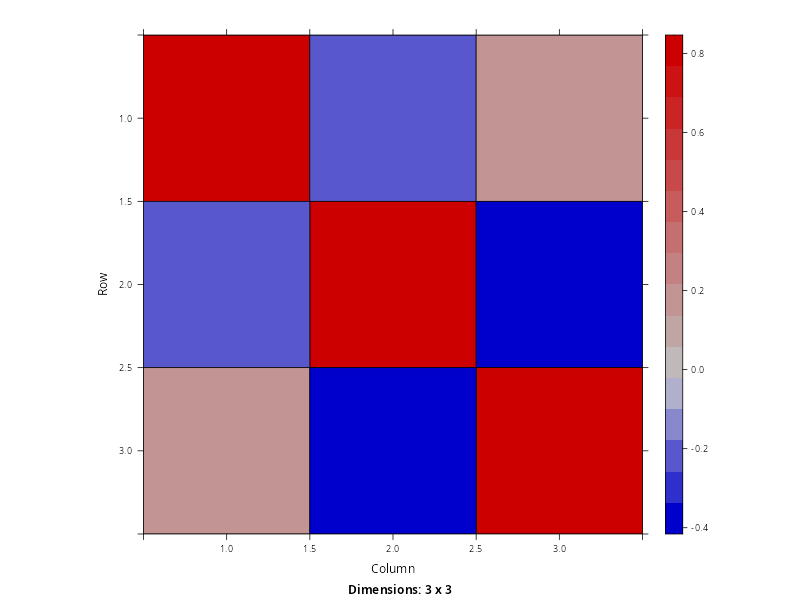

In [ ]:
gls.mod <- gls(score ~ time, correlation=corSymm(form= ~1|id), data=selfesteem.long)

Sigma.1 <- getVarCov(gls.mod, individual='1')
print(Sigma.1)
image(as(Sigma.1, "Matrix"))

This time, we have kept the variances *fixed* but have allowed the *correlation* to change between the repeated measurements.

3 x 3 Matrix of class "dsyMatrix"
           [,1]       [,2]       [,3]
[1,]  0.3044901 -0.1272857  0.2273559
[2,] -0.1272857  0.7448897 -0.5157849
[3,]  0.2273559 -0.5157849  1.3055278


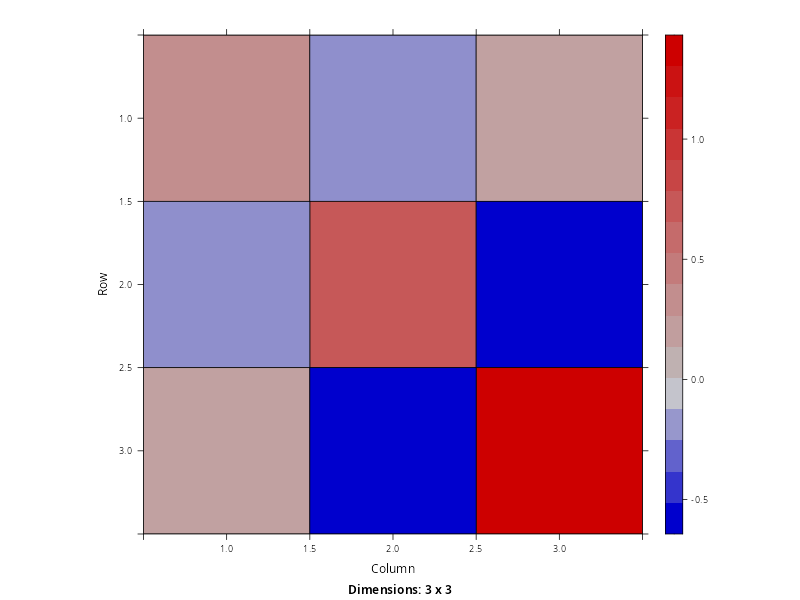

In [ ]:
gls.mod <- gls(score ~ time, correlation=corSymm(form= ~1|id), weights=varIdent(form= ~1|time), data=selfesteem.long)
Sigma.1 <- getVarCov(gls.mod, individual='1')
Sigma.1 <- as(Sigma.1, "Matrix")
print(Sigma.1)
image(Sigma.1)

## Comparing Covariance Structures

In [ ]:
gls.mod.1 <- gls(score ~ time, correlation=corCompSymm(form= ~1|id),                                  data=selfesteem.long, method='ML') # compound symmetry + homogeneity of variance
gls.mod.2 <- gls(score ~ time, correlation=corCompSymm(form= ~1|id), weights=varIdent(form= ~1|time), data=selfesteem.long, method='ML') # compound symmetry + heterogeneity of variance
gls.mod.3 <- gls(score ~ time, correlation=    corSymm(form= ~1|id),                                  data=selfesteem.long, method='ML') # general symmetric + homogeneity of variance
gls.mod.4 <- gls(score ~ time, correlation=    corSymm(form= ~1|id), weights=varIdent(form= ~1|time), data=selfesteem.long, method='ML') # general symmetric + heterogeneity of variance

anova(gls.mod.1, gls.mod.2, gls.mod.3, gls.mod.4)

          Model df      AIC      BIC    logLik   Test  L.Ratio p-value
gls.mod.1     1  5 83.60855 90.61453 -36.80427                        
gls.mod.2     2  7 83.04092 92.84930 -34.52046 1 vs 2 4.567627  0.1019
gls.mod.3     3  7 84.66271 94.47109 -35.33136                        
gls.mod.4     4  9 83.11777 95.72855 -32.55888 3 vs 4 5.544944  0.0625

The degrees of freedom here are a count of the number of parameters that need to be estimated. As each model has the same mean structure, there in always a single *intercept* parameter and two `time` parameters. The remaining count are those associated with the covariance structure. So, we can see that `gls.mod.1` has 2 covariance parameters corresponding to the constant variance and constant correlation. Both models 2 and 3 have 4 covariance parameters, corresponding to either 1 fixed variance and 3 free correlations, or 3 free variances and 1 fixed correlation. Finally, model 4 has 6 covariance parameters, corresponding to 3 free variances and 3 free correlations.

In terms of the inferential tests, these are computed as a *likelihood ratio*, but only between models that are *nested*. In other words, one model is a subset of another. In this example, this is only true of those models that share a correlation structure. So the tests here are based on assessing whether the additional flexibility added by allowing heterogeneity of variance is warranted. The $p$-value here is also based on asymptotic theory, so we have to be quite cautious in small samples. So, for our current purpose, the $p$-value here is not so useful, but could be if we were certain we wanted a specific correlation structure and our only remaining question was whether the additional `weights=` argument was needed.

So, in terms of actually deciding between these covariance structures, we turn to model comparisons procedures using the AIC and BIC. These were explored last semester as part of the [ANOVA workshop](https://github.com/PCHN63101-Advanced-Data-Skills/Model-Comparisons-ANOVA/blob/main/ANOVA-workshop.ipynb), so it may be worth quickly revising this before going any further. ...

In terms of choosing between AIC and BIC, we will favour BIC here because BIC is more focussed on the *data-generating process* than on *prediction*. It punishes complexity much harder than AIC, meaning the data really needs to suggest a complex structure is needed for BIC to allow it. This makes BIC more favourable in terms of developing a *parsimonious* model of the data-generating process.

Focussing just on BIC, we are looking for the model with the *smallest* values of BIC. In this example, it is the model with a *compound symmetric* correlation structure and *homogeneity of variance*. However, the *absolute* value of BIC is not of importance. What matters is the *difference*. Between the model with largest and smallest BIC, the change is $\Delta\text{BIC} = 95.73 - 90.61 = 5.11$. If we look back at the interpretation guidance we gave last semester for interpreting BIC (in the [ANOVA workshop](https://github.com/PCHN63101-Advanced-Data-Skills/Model-Comparisons-ANOVA/blob/main/ANOVA-workshop.ipynb)), a change of around 5 is considered *positive evidence favouring the lower-BIC model*. This is not super strong evidence, but it is suggesting that the additional complexity is *not warranted* in order to explain the data. All other comparisons indicate *smaller* changes in BIC, meaning that although the simplest covariance structure is supported, this is not a slam-dunk by any means. In this situation, we would likely use the simplest covariance structure, but we would be aware of the fact that the evidence in support of this structure is not overwhelming and that something more complex *could* be warranted if we had more data or repeated the experiment again.

## Assumptions and Visualisations
Before we get to discussing the tricky topic of inference, we also need to consider how to check the assumptions and visualise the GLS model. Although the plain `lm()` functions allows a variety of diagnostic plots, calling `plot()` on a GLS model will only give us a single visualisation. As such, if we want something similar we need to construct these plots ourselves, with some caveats.

### Assumptions Plots
In principle, all the plots we saw previously with `lm()` can still be defined using a model fit using `gls()`. However, there are two important caveats. 

Firstly, this is true only when working with the *corrected* errors. In other words, the errors that result from *removing* the covariance structure. Technically, this means we need to assume that the covariance structure we have is *correct*, as the assumptions of the normal linear model only apply if we have managed to remove the covariance structure *perfectly*. Given that this is not going to be true under FGLS, we need to be slightly more cautious about the interpretation of these types of plots.

Secondly, *leverage* and *Cook's Distance* are not defined under GLS. It may be possible to calculate some variant that is *similar* in spirit, but this is messy and would need to be scripted manually. As such, we will skip the leverage plot and, in its place, provide a visualisation of the covariance structure as a diagnostic measure, to make sure the estimated structure is as expected.

In the drop-down below is the definition of a function called `plot.gls()` that will create some visualisations that are similar in spirit to those from the normal linear model. These are all calculated using the residuals extracted using `resid(mod, type='normalized')`, which are residuals that have been *corrected* for the covariance structure and are *standardised*.  

In [ ]:
plot.gls <- function(mod, timeseries=FALSE){

  w <- resid(mod, type="normalized")
  f <- fitted(mod)

  par(mfrow=c(2,2))

  # Residuals vs fitted
  plot(f, w, main='Residuals vs fitted')
  lines(lowess(f,w))

  # Normal Q-Q
  qqnorm(w) 
  qqline(w)
  
  # Scale-Location
  plot(f, sqrt(abs(w)), main='Scale-Location')
  lines(lowess(f,sqrt(abs(w))))

  # Either plot of the ACF, or a visualisation of the marginal covariance structure
  if (timeseries==TRUE){
    acf(w)                                   
  } else {
    V <- getVarCov(mod)
    graphics::image(as.matrix(V)[nrow(V):1, ], main='Marginal covariance structure')
  }
}

Applying this function to the results from the model with the unconstrained covariance structure gives

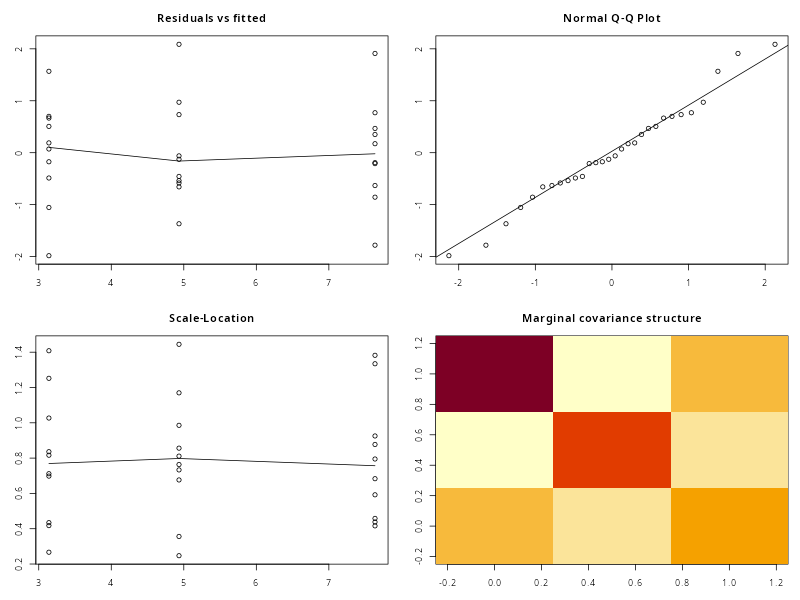

In [ ]:
plot.gls(gls.mod.Unconstrained )

As way of comparison, the model with the compound symmetric structure gives

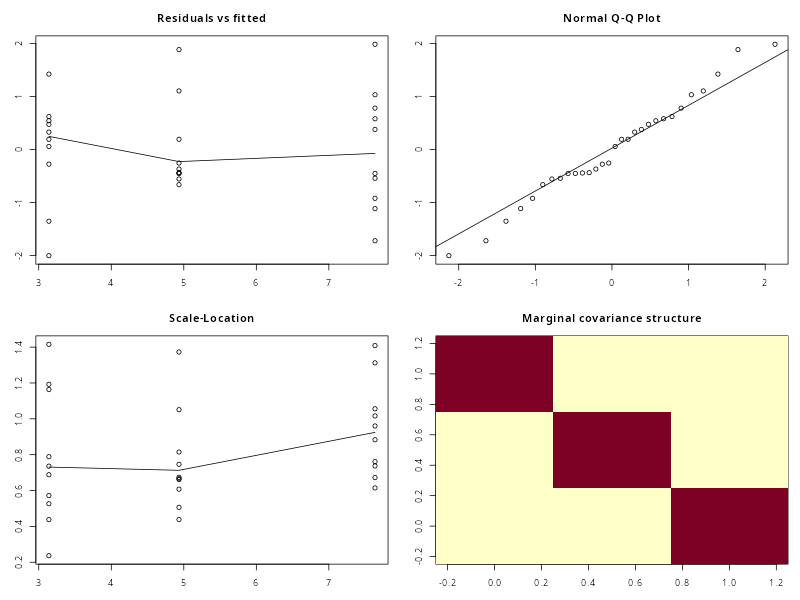

In [ ]:
plot.gls(gls.mod.CompSymm)

which does appear qualitatively *worse*, thus suggesting that a more complex covariance structure provides a better model fit.

### Visualising the Model